# Chapter-05. 数据读取

## 【章节目标】
- 理解pytorch数据读取的流程
- 掌握定义DataSet的方法
- 掌握定义DataLoader的方法
- 掌握数据读取方法

## 【章节内容】
### 5.1 Pytorch数据读取
#### 1）数据模块

数据模块通常分为四个子模块，分别是收集、划分、读取和处理。

- 首先要收集数据，数据分为样本和标签 。

- 数据划分：要将数据划分为训练集、验证集和测试集。

- 数据读取：DataLoader。DataLoader还分为Sampler和Dataset两个子模块。

    - Sampler的作用是生成索引，也就是样本的序号。
    - Dataset是根据索引读取图片和标签。

- 数据预处理：pytorch中是通过transforms实现的，见06。

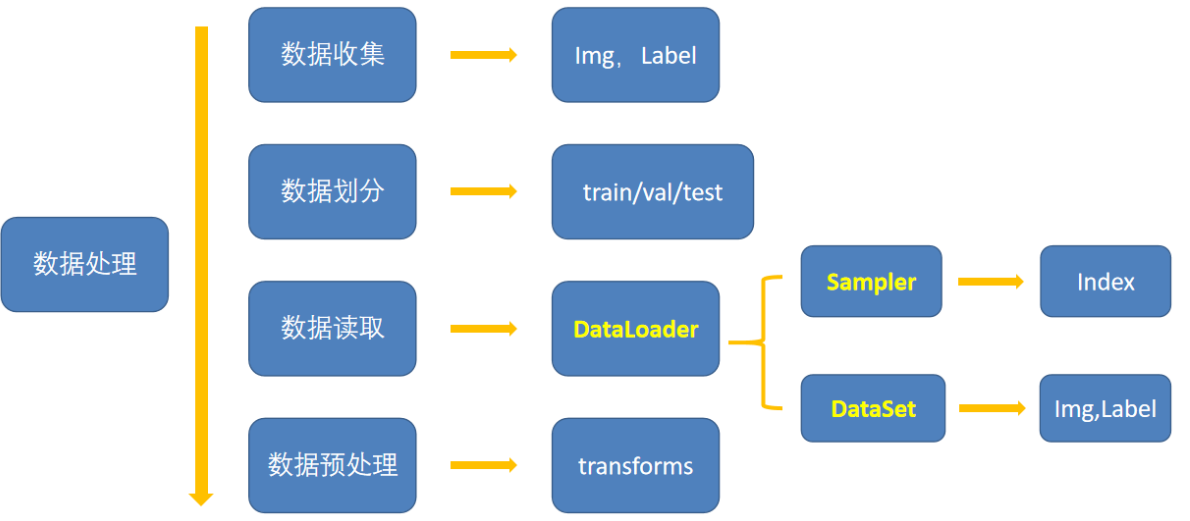

#### 2）DataLoader

pytorch数据读取的核心是torch.utils.data.DataLoader类，具有以下特性：

- 支持map-style datasets和iterable-style datasets
- 自定义数据读取顺序
- 自动批量化
- 单线程/多线程读取
- 自动内存锁页

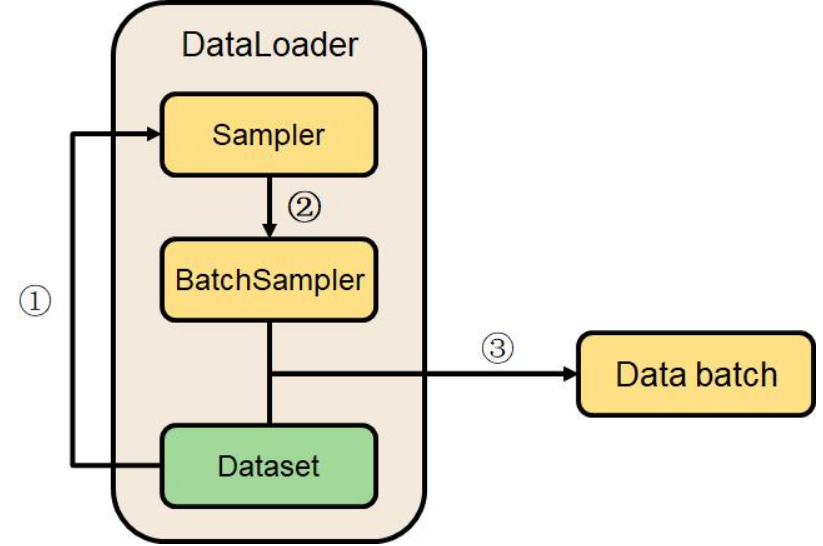

DataLoader的参数如下，主要涉及DataSet、sample、collate_fn、pin_memory

- dataset: Dataset类，决定数据从哪读取

- batchsize: 批大小

- num_works: 是否多进程读取数据

- shuffle:每个epoch是否乱序

- drop_last：当样本数不能被batchsize整除时，是否舍弃最后一批数据

In [ ]:
# DataLoader(dataset, batch_size=1, shuffle=False, sampler=None,
#            batch_sampler=None, num_workers=0, collate_fn=None,
#            pin_memory=False, drop_last=False, timeout=0,
#            worker_init_fn=None, *, prefetch_factor=2,
#            persistent_workers=False)

#### 2）pytorch数据读取流程

pytorch读取数据的整体处理流程如下图：

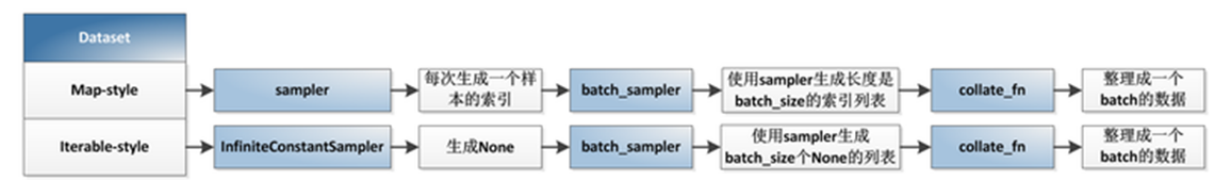

无论是map-style还是iterable-style dataset整体流程都是

- 先用采样器采样，采样一次得到一个样本的索引（iterable-style dataset不能通过索引取值，所以使用的是一个虚假的采样器，每次生成None）。

- 使用batch_sampler生成长度为batch_size的索引列表（实际是使用sampler采样batch_size次）。

- 使用collate_fn将batch_size长度的列表整理成batch样本（tensor格式）。

#### 3）DataSet Types

pytorch支持两种类型的数据集map-style dataset和iterable-style dataset。

##### 3.1）map-style dataset：torch.utils.data.Dataset

功能：Dataset抽象类，所有自定义的Dataset需要继承它，并且复写**__getitem__()方法和__len__()**方法

- __getitem__()：接收一个索引，返回一个样本，即传入一个给定的索引Index之后，如何按此索引进行单例或切片访问，单例还是切片视Index是单值还是列表。

- __len__()：返回数据集的样本总数

**注意: DataLoader默认构造的采样器返回的都是整数索引，如果dataset的索引不是整数，需要自定义采样器。**

Pytorch源码如下：

In [ ]:
class Dataset(object):
    r"""An abstract class representing a :class:`Dataset`.

    All datasets that represent a map from keys to data samples should subclass
    it. All subclasses should overwrite :meth:`__getitem__`, supporting fetching a
    data sample for a given key. Subclasses could also optionally overwrite
    :meth:`__len__`, which is expected to return the size of the dataset by many
    :class:`~torch.utils.data.Sampler` implementations and the default options
    of :class:`~torch.utils.data.DataLoader`.

    .. note::
      :class:`~torch.utils.data.DataLoader` by default constructs a index
      sampler that yields integral indices.  To make it work with a map-style
      dataset with non-integral indices/keys, a custom sampler must be provided.
    """

    def __getitem__(self, index):
        raise NotImplementedError

    def __add__(self, other):
        return ConcatDataset([self, other])

自定义数据集要继承上述Dataset基类，并实现__getitem__()方法和__len__()方法：

In [ ]:
class XXXDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.label_name = XXX #存储数据标签
        self.data_info = XXX # data_info存储所有图片路径和标签
        self.transform = XXX #数据预处理方法

    def __getitem__(self, index):
        path_img, label = self.data_info[index]#提取一条数据

        return img, label

    def __len__(self):
        return len(self.data_info) #返回数据长度

##### 3.2）Iterable-style datasets：torch.utils.data.IterableDataset

- 可迭代型数据集是torch.utils.data.IterableDataset的子类，需要实现__iter__()协议，表示对数据样本的一轮迭代。

pytorch源码如下：

In [ ]:
class IterableDataset(Dataset):
    def __iter__(self):
        raise NotImplementedError

    def __add__(self, other):
        return ChainDataset([self, other])

- iterable-style dataset类似python的可迭代对象。使用iter()方法会得到一个迭代器，每次调用next()会得到下一个样本。无法使用索引取元素。所以就不能使用采样器采样得到索引，再使用索引得到样本。

- dataloader的实现中，对于可迭代类型的数据集会使用一个虚假采样器InfiniteConstantSampler。每次调用都返回None。这个采样器的目的就是为了在batch_sample时控制采样的次数。

源代码如下：

In [ ]:
class _InfiniteConstantSampler(Sampler):
    r"""Analogous to ``itertools.repeat(None, None)``.
    Used as sampler for :class:`~torch.utils.data.IterableDataset`.

    Args:
        data_source (Dataset): dataset to sample from
    """

    def __init__(self):
        super(_InfiniteConstantSampler, self).__init__(None)

    def __iter__(self):
        while True:
            yield None

#### 4）Sampler
- 对于IterableDataset来说，数据读取的顺序是由迭代器确定好的，无法改变。（回想下python的迭代器，只能通过循环调用next()方法，依次拿到下一个样本。不能改变原有的次序。）

- 对may-style Dataset来说，sampler可以在数据读取时指定读取的顺序。

- 默认构建采样器：通过指定DataLoader的shuffle参数来确定是顺序读取还是乱序读取。如果shuffle=True，DotaLoader会自动构造一个RandomSampler采样器，shuffle=False，会构造SequentialSample采样器。

- 自定义：自定义采样器每次返回下一个采样的索引。可使用DataLoader的sampler参数设置自定义的采样器sampler。

**注意：采样器返回的都是样本索引，不是样本本身。需要再根据索引得到样本。**

batch_sampler：

如果一个采样器sampler一次返回批量大小的索引列表，那么就叫做batch_sampler。

- 默认构建：如果指定DataLoader的batch_size和drop_last参数，就会基于sampler（采样器）自动构造一个batch_sampler（批量采样器）。

- 自定义：map-style 数据集可以自定义批量采样器。并使用batch_sampler参数设置。

#### 5）collate_fn

collate_fn从字面上看就是整理函数，是对batch_sampler批量采样器返回的长度是batch_size的索引列表进行加工，处理成pytorch支持的数据类型（通常都是第一维是batch_size大小的tensor）。

**注意：采样器sampler/batch_sampler返回的都是样本索引，collate_fn的输入是批量大小的样本列表。所以在传给collate_fn前要根据索引取样本。**

如果是may-style数据集，这个操作实现类似于（官网给的例子）：

In [ ]:
for indices in batch_sampler:
    yield collate_fn([dataset[i] for i in indices])

如果是iterable-style数据集，操作实现类似于：

In [ ]:
dataset_iter = iter(dataset)
for indices in batch_sampler:
    yield collate_fn([next(dataset_iter) for _ in indices])

通过观察pytorch源码发现：

- 如果不指定collate_fn，会使用默认的collate_fn函数，这个函数的功能就是将各种类型的数据转化成tensor。

- 也可以自定义collare_fn函数，然后通过collate_fn参数设置，在自定义的函数中可以增加一些需要的操作。（例如，将每个样本padding到当前batch的最大样本长度。任何想要对批量数据进行的操作都要定义在这个函数中。）

#### 6）pin_memory

pin_memory是指锁页内存，什么是锁页内存？

- 内存分为锁页和不锁页，锁页内存存的东西在任何情况下都不会与机器的虚拟内存（虚拟内存就是硬盘）进行交换。不锁页内存在主机内存不足时，数据会存放到虚拟内存。

- 如果pin_memory=True，那么生成的数据都会放在锁页内存上，此时将tensor拷贝到GPU的显存会更快。这个参数默认是Flase。机器硬件好的同学可以改为True看下是否速度有提升。

### 5.2 自定义猫狗数据集

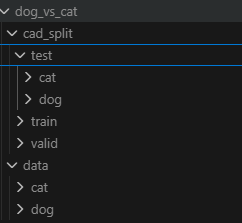 数据集总体

- 1.分割训练集（train）、验证集（val）和测试集
- 2.定义MyDataset类
- 3.实现数据读取

#### 1）分割训练集

通过python操作文件将数据分割为三个文件夹：

训练集：train 0.8  
验证集：val 0.1  
测试集：test 0.1  

**代码如下：**

In [2]:
import os
from shutil import copyfile, copy
import random
from tqdm import tqdm
path = 'dog_vs_cat'
random.seed(1)

dataset_dir = os.path.join(path, 'data')
split_dir = os.path.join(path, 'cad_split')
split_dirs = [os.path.join(split_dir, name) for name in ['train', 'valid', 'test']]
print(os.listdir(dataset_dir))
#设定分割比例
train_pct = 0.8
valid_pct = 0.1
test_pct = 0.1

# 遍历目录
for root, dirs, files in os.walk(dataset_dir):
    #print('for', root, dirs)
    for sub_dir in dirs: #提取子目录
        imgs = os.listdir(os.path.join(root, sub_dir))
        imgs = list(filter(lambda x: x.endswith('.jpg'), imgs))
        random.shuffle(imgs)
        img_count = len(imgs)

        train_point = int(img_count * train_pct)
        valid_point = int(img_count * (train_pct + valid_pct))
        images = [imgs[:train_point], imgs[train_point:valid_point], imgs[valid_point:]]
        out_dirs = [os.path.join(dir_, sub_dir) for dir_ in split_dirs] # 拼接输出目录
        print(out_dirs)
        for image, out_dir in zip(images, out_dirs): # 遍历分割好的图片和输出目录路径
            if not os.path.exists(out_dir): # 输出目录的路径要是没文件夹就创建
                os.makedirs(out_dir)
            for img in tqdm(image, desc = out_dir):
                target_path = os.path.join(out_dir, img)
                src_path = os.path.join(dataset_dir, sub_dir, img)
                copyfile(src_path, target_path) 
                # 分割后的图片从原文件夹复制到目标路径下
        print('Class:{}, train:{}, valid:{}, test:{}'.format(sub_dir, train_point, valid_point - train_point, img_count - valid_point))

['cat', 'dog']
['dog_vs_cat\\cad_split\\train\\cat', 'dog_vs_cat\\cad_split\\valid\\cat', 'dog_vs_cat\\cad_split\\test\\cat']


dog_vs_cat\cad_split\test\cat: 100%|██████████| 1250/1250 [00:00<00:00, 1510.69it/s]


Class:cat, train:10000, valid:1250, test:1250
['dog_vs_cat\\cad_split\\train\\dog', 'dog_vs_cat\\cad_split\\valid\\dog', 'dog_vs_cat\\cad_split\\test\\dog']


dog_vs_cat\cad_split\test\dog: 100%|██████████| 1250/1250 [00:00<00:00, 1563.53it/s]

Class:dog, train:10000, valid:1250, test:1250


#### 2）定义DataSet

In [2]:
from torch.utils.data import Dataset
import random
from PIL import Image
import os
import numpy as np
random.seed(1)

class DogCatDataset(Dataset):
    def __init__(self, data_dir, transform = None):
        """
        猫狗分类任务的Dataset
        :param data_dir: str, 数据集所在路径
        :param transform: torch.transform，数据预处理
        """
        self.label_name = {'cat': 0, 'dog': 1}
        self.data_info = self.get_img_info(data_dir)
        self.transform = transform
    
    def __getitem__(self, index):
        path_img, label = self.data_info[index]
        img = Image.open(path_img).convert('RGB')
        if self.transform is not None:
            img = self.transform(img)
        return img, label
    
    def __len__(self):
        return len(self.data_info)

    def get_img_info(self, data_dir):
        data_info = list()
        for root, dirs, _ in os.walk(data_dir):
            # 遍历类别子目录
            for sub_dir in dirs: #[cat, dog]
                img_names = os.listdir(os.path.join(root, sub_dir))
                img_names = list(filter(lambda x: x.endswith('.jpg'), img_names))
                label = self.label_name[sub_dir]
                data_info.extend([(os.path.join(root, sub_dir, img), label) for img in img_names])
        return data_info

#### 3）定义DataLoader

In [5]:
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import torch

def set_seed(seed = 1):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)

set_seed()

path = 'dog_vs_cat'
BATCH_SIZE = 4

split_dir = os.path.join(path, "cad_split")
train_dir = os.path.join(split_dir, "train")
valid_dir = os.path.join(split_dir, "valid")

#定义预处理方法
train_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.RandomCrop(32, padding = 4),
    transforms.ToTensor()
])

valid_transfor = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor()
])

# 构建MyDataset实例
# train_data = DogCatDataset(data_dir=train_dir)
# valid_data = DogCatDataset(data_dir=valid_dir)
train_data = DogCatDataset(data_dir = train_dir, transform = train_transform)
valid_data = DogCatDataset(data_dir = valid_dir, transform = train_transform)

# 构建DataLoader
train_loader = DataLoader(dataset = train_data, batch_size = BATCH_SIZE, shuffle = True)
valid_loader = DataLoader(dataset = valid_data, batch_size = BATCH_SIZE)

#### 4）实现数据批量读取

In [6]:
for data in train_loader:
    print(data)#一个批次的x和y  x: N C  H W y:N #N是一个批次的大小
    print(data[0][0].shape)#x的第一个样本shape
    print(data[0].shape[0])#批次大小
    break

[tensor([[[[0.0000, 0.0000, 0.0000,  ..., 0.8745, 0.8588, 0.8471],
          [0.0000, 0.0000, 0.0000,  ..., 0.8824, 0.8706, 0.8549],
          [0.0000, 0.0000, 0.0000,  ..., 0.8863, 0.8784, 0.8627],
          ...,
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],

         [[0.0000, 0.0000, 0.0000,  ..., 0.8510, 0.8392, 0.8235],
          [0.0000, 0.0000, 0.0000,  ..., 0.8588, 0.8471, 0.8353],
          [0.0000, 0.0000, 0.0000,  ..., 0.8627, 0.8549, 0.8392],
          ...,
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],

         [[0.0000, 0.0000, 0.0000,  ..., 0.8471, 0.8314, 0.8196],
          [0.0000, 0.0000, 0.0000,  ..., 0.8627, 0.8510, 0.8314],
          [0.0000, 0.0000, 0.0000,  ..., 